## Mean Squared Error (MSE) Loss Function

### Theory
The **Mean Squared Error (MSE)** quantifies the average squared difference between the actual values and the predicted values.

**Mathematical Formula:**
$$
J(w, b) = \frac{1}{n} \sum_{i=1}^{n} \left( y^{(i)} - \hat{y}^{(i)} \right)^2
$$
where:
- $y^{(i)}$ = Actual target value
- $\hat{y}^{(i)} = w \cdot X^{(i)} + b$ = Predicted value
- $n$ = Number of training samples

### Why MSE?
- It is **differentiable**, making it suitable for Gradient Descent.
- Squaring the error penalizes large deviations more heavily.
- It is a **convex** function, guaranteeing a single global minimum.

**Role:** MSE serves as our objective function. The goal of Gradient Descent is to find the values of $w$ and $b$ that **minimize** this loss.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math
import warnings

In [51]:
# ====================================
# MODULE :1 MSE LOSS
# ====================================

def MSE_loss(y,y_pred):
    
    mse=np.mean((y - y_pred)**2)
    return mse # scaling factor help in calculating GD
    

## Gradient Computation using Calculus

### Mean Squared Error Loss Function
$$
J(w, b) = \frac{1}{n} \sum_{i=1}^{n} \left( y^{(i)} - \hat{y}^{(i)} \right)^2, \quad \text{where } \hat{y}^{(i)} = w \cdot X^{(i)} + b
$$

### Analytical Gradient Formulation (Calculus)

To minimize the loss, we compute the partial derivatives with respect to $w$ and $b$ using the **Chain Rule**.

#### Derivation for Weight Gradient ($\frac{\partial J}{\partial w}$):
$$
\frac{\partial J}{\partial w} = \frac{1}{n} \sum_{i=1}^{n} 2(y^{(i)} - \hat{y}^{(i)}) \cdot (-X^{(i)})
$$

$$
\frac{\partial J}{\partial w} = -\frac{2}{n} \sum_{i=1}^{n} X^{(i)} (y^{(i)} - \hat{y}^{(i)})
$$

#### Derivation for Bias Gradient ($\frac{\partial J}{\partial b}$):
$$
\frac{\partial J}{\partial b} = \frac{1}{n} \sum_{i=1}^{n} 2(y^{(i)} - \hat{y}^{(i)}) \cdot (-1)
$$

$$
\frac{\partial J}{\partial b} = -\frac{2}{n} \sum_{i=1}^{n} (y^{(i)} - \hat{y}^{(i)})
$$

These gradients (`dw` and `db`) indicate the direction of steepest ascent. We move in the **opposite direction** during updates.



In [52]:
# ============================================
# MODULE : 2 GRADIENT DECENT (CALCULUS)
# ============================================


def MSE_gardient_decent(y,X,w,b):
    
    #length of training data
    n=len(y)
    
    #predicted target value
    y_pred = w*X + b
    
    #Deviation for weight gradient
    dw = - (2/n)*np.sum(X*(y-y_pred))
    
    #Deviation for biase dradient
    db = -(2/n)*np.sum(y - y_pred)
    
    return dw,db

## Module 3: Gradient Descent Loop – Finding Optimal Parameters

### Theory
Gradient Descent is an iterative optimization algorithm that minimizes the loss function by repeatedly updating the model parameters ($w$ and $b$) in the direction of the negative gradient.

### Full Algorithm

**Inputs:**
- Training data $(X, y)$
- Initial values $w_{init}$, $b_{init}$
- Learning rate $\alpha$
- Number of iterations

**Steps:**
1. Initialize $w = w_{init}$, $b = b_{init}$
2. For each iteration:
   - Compute predictions: $\hat{y} = w \cdot X + b$
   - Calculate gradients $dw$ and $db$
   - Update parameters:
     $$
     w \leftarrow w - \alpha \cdot dw \\
     b \leftarrow b - \alpha \cdot db
     $$
   - Compute current loss and store it
3. Return final $w$, $b$, and loss history

### Key Concepts
- **Convergence:** The process stops when gradients become very small or after a fixed number of iterations.
- **Loss History:** Helps visualize how the model improves over time and diagnose learning rate problems.

In [53]:
# ===================================================================
# MODULE : 3 GRADIENT DECENT LOOP (Finding global mimima for w and b)
# ===================================================================
def gardient_decent(X,y,w_init,b_init,learning_rate,n_iter):
    
    #Initialising weight(W) and bias(b)
    w,b = w_init,b_init 
    
    #loss data
    loss_hist=[]
    
    #Itrating to Minimum W and b
    
    for i in range(n_iter):
        
        dw,db = MSE_gardient_decent(y,X,w,b)
        
        #Updating dw and db
        w -= learning_rate*dw
        b -= learning_rate*db
        
        #calculating loss 
        loss= MSE_loss(y, w*X+b ) #(actual - predicted)
        
        #upading in loss history
        loss_hist.append(loss)
        
        
    """#Values of w,b and loss 
        if i%100 == 0:
            print(f"Interation {i} : w={w:.5f}, b={b:.5f} and loss={loss:.5f}")"""
        
            
            
    
    return w,b,loss_hist        
    
     


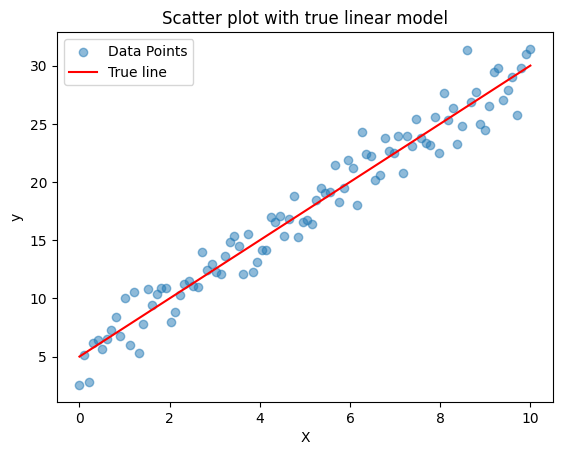

In [ ]:
# ======================================================
# MODULE : 4 GENRATING RANDOM FEAURES(X) AND TARGET(y) 
# ======================================================

np.random.seed(55)#To get the same values every time
X= np.linspace(0,10,100)# 100 values starting from 0 to 10

#Setting the actual parameters
t_w,t_b= 2.5,5.0

#Adding random noise
noise=np.random.normal(0,1.5,size=len(X))

#Target y values 
y = t_w*X + t_b + noise 


#visualising feature X and target Y
plt.scatter(X,y,alpha=0.5,label='Data Points')
plt.plot(X, t_w*X + t_b, color='red',label='True line')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Scatter plot with true linear model')
plt.legend()
plt.show() 




## Learning Rate ($\alpha$) – Theory and Practical Effects

The **learning rate** is a critical hyperparameter that controls the size of the step taken during each parameter update:

$$
w \leftarrow w - \alpha \cdot dw \qquad
b \leftarrow b - \alpha \cdot db
$$

#### Comparison of Three Common Learning Rates:

**1. Small Learning Rate** (e.g., $\alpha = 0.001$)
- Takes very small steps.
- **Pros:** Stable, low risk of overshooting.
- **Cons:** Extremely slow convergence. May require many thousands of iterations.
- Best when the loss surface is steep or noisy.

**2. Moderate (Good) Learning Rate** (e.g., $\alpha = 0.01$)
- Balanced step size.
- **Pros:** Fast yet stable convergence. Smooth decrease in loss.
- **Cons:** May still be slow on very complex problems.
- **Recommended starting point** for most linear regression tasks.

**3. Large Learning Rate** (e.g., $\alpha = 0.1$ or higher)
- Takes big jumps.
- **Pros:** Very fast initial progress.
- **Cons:** Can overshoot the minimum, oscillate, or even diverge (loss increases).
- Mathematically: Large $\alpha$ amplifies the gradient, leading to instability.

**Tip:** Always plot the **loss history** to diagnose learning rate issues. A good learning rate produces a steadily decreasing, smooth curve.

--------------------------------------------------------------------------------
For Learning rate: 0.1
Learning rate is too high makes the model diverge.(unstable divergence)
True: w=2.5, b=5.0
Estimated: w=nan, b=nan

--------------------------------------------------------------------------------
For Learning rate: 0.01
Learning rate is good and model converges nicely.(good convergence)
True: w=2.5, b=5.0
Estimated: w=2.5040, b=4.9969

--------------------------------------------------------------------------------
For Learning rate: 0.001
converges slowly and may still be far from optimum after 1000 iterations. ( stable but slower convergence)
True: w=2.5, b=5.0
Estimated: w=2.9157, b=2.2592

--------------------------------------------------------------------------------
For Learning rate: 0.0001
converges slowly and may still be far from optimum after 1000 iterations. ( stable but slower convergence)
True: w=2.5, b=5.0
Estimated: w=3.1470, b=0.6985

------------------------------

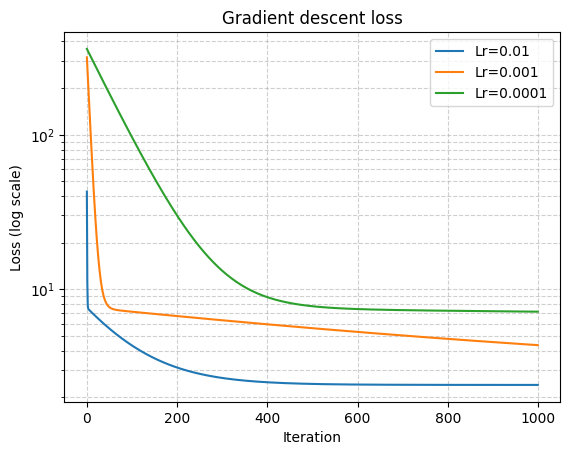

In [74]:
# ==============================================================
# MODULE : 5 TESTING DIFFRENT LEARNING RATE WITH FIX ITERATION 
# ==============================================================

#initialising weight and bias
w_init,b_init=0.0,0.0

# learning rate array
lear_rate=[0.1,0.01,0.001,0.0001]
iteration=1000

fig,ax =plt.subplots()
print("----"*20)


for i in range(len(lear_rate)):
    
    #Running model for diffrent learning rate
    w_final ,b_final,loss = gardient_decent(X,y,w_init,b_init,lear_rate[i],iteration)
    
    print(f"For Learning rate: {lear_rate[i]}")
    
    if (math.isnan(w_final) or math.isnan(b_final)):
        print("Learning rate is too high makes the model diverge.(unstable divergence)")
        warnings.filterwarnings("ignore", category=RuntimeWarning)#As w=nan,b=nan and loss=nan
        
    elif(abs(t_w - w_final)<1e-2 or abs(t_b - b_final)<1e-2):
        print("Learning rate is good and model converges nicely.(good convergence)")
        ax.plot(range(iteration),loss,'-',label=f"Lr={lear_rate[i]}")
        
    else:
        print(f"converges slowly and may still be far from optimum after {iteration} iterations. ( stable but slower convergence)")
        ax.plot(range(iteration),loss,'-',label=f"Lr={lear_rate[i]}")        
        
   
    print(f"True: w={t_w}, b={t_b}")
    print(f"Estimated: w={w_final:.4f}, b={b_final:.4f}\n")
    print("----"*20)
    

ax.set_yscale('log')
ax.set_xlabel('Iteration')
ax.set_ylabel('Loss (log scale)')
ax.set_title('Gradient descent loss')
ax.grid(True,which='both',linestyle='--',alpha=0.6)
ax.legend()
plt.show() 

    
    

## Module 4: Verification using `np.polyfit`

### Why Verify?
We compare our custom Gradient Descent implementation with NumPy’s analytical solution (`np.polyfit`) to validate correctness and accuracy.

### Theory
`np.polyfit(X, y, 1)` solves linear regression using the **Least Squares** closed-form solution:

$$
w = \frac{n\sum(xy) - \sum x \sum y}{n\sum(x^2) - (\sum x)^2}, \quad
b = \frac{\sum y - w \sum x}{n}
$$

This gives the **optimal** parameters without iteration.

### Purpose of This Module:
- Check how close our Gradient Descent result is to the mathematical optimum.
- Visualize and compare:
  - Original data points
  - True underlying line
  - Our Gradient Descent line
  - Polyfit (analytical) line

polyfit: w=2.4993, b=5.0283
Difference: w=4.72e-03, b=3.14e-02


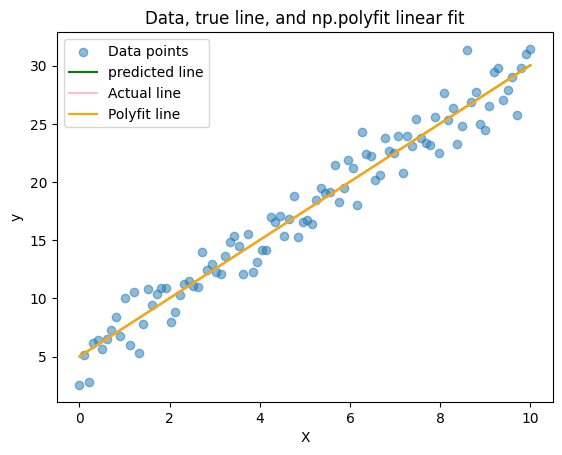

In [63]:
# ====================================================================================================
# MODULE : 6 VERIFICATION USING NUMPY'S POLYNOMIAL FIT and MODEL WITH BASELINE LEARNING RATE(lr=0.01)
# ====================================================================================================

from numpy import polyfit

#Intilizing weights and bais
w_init,b_init=0.0,0.0

#Serring learining rate and number of iterations
lr=0.01
iteration=1000

w_final ,b_final,loss = gardient_decent(X,y,w_init,b_init,lr,iteration)

poly_w, poly_b = polyfit(X, y, 1)
print(f"polyfit: w={poly_w:.4f}, b={poly_b:.4f}")
print(f"Difference: w={abs(w_final-poly_w):.2e}, b={abs(b_final-poly_b):.2e}")

plt.scatter(X, y, alpha=0.5, label='Data points')
plt.plot(X, w_final * X + b_final, color='green', label='predicted line')
plt.plot(X, t_w * X + t_b, color='pink', label='Actual line')
plt.plot(X, poly_w * X + poly_b, color='orange', label='Polyfit line')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Data, true line, and np.polyfit linear fit')
plt.legend()
plt.show()

